In [ ]:
from pathlib import Path
from types import SimpleNamespace
import math
import pickle
import random
import tarfile
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset


CIFAR10_LABELS = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)


class CIFAR10TensorDataset(Dataset):
    def __init__(self, images, labels, mean=CIFAR10_MEAN, std=CIFAR10_STD):
        self.images = images.astype(np.uint8, copy=False)
        self.labels = labels.astype(np.int64, copy=False)
        self.mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
        self.std = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = torch.from_numpy(self.images[index]).permute(2, 0, 1).float() / 255.0
        image = (image - self.mean) / self.std
        label = torch.tensor(self.labels[index], dtype=torch.long)
        return image, label


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def load_pickle_batch(batch_path):
    with Path(batch_path).open("rb") as handle:
        raw = pickle.load(handle, encoding="bytes")
    images = raw[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(raw[b"labels"], dtype=np.int64)
    return images, labels


def load_cifar10_bundle(archive_path, *, val_size=5_000, seed=42):
    archive_path = Path(archive_path)
    extract_root = archive_path.parent / ".data"
    with tarfile.open(archive_path, "r:gz") as handle:
        handle.extractall(extract_root)
    extracted_dir = extract_root / "cifar-10-batches-py"
    train_parts = []
    train_targets = []

    for batch_id in range(1, 6):
        images, labels = load_pickle_batch(extracted_dir / f"data_batch_{batch_id}")
        train_parts.append(images)
        train_targets.append(labels)

    train_images = np.concatenate(train_parts, axis=0)
    train_labels = np.concatenate(train_targets, axis=0)
    test_images, test_labels = load_pickle_batch(extracted_dir / "test_batch")

    with (extracted_dir / "batches.meta").open("rb") as handle:
        meta = pickle.load(handle, encoding="bytes")
    labels = [name.decode("utf-8") for name in meta[b"label_names"]]

    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(train_images))
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]

    return SimpleNamespace(
        archive_path=Path(archive_path),
        extracted_dir=extracted_dir,
        labels=labels,
        train_images=train_images[train_indices],
        train_labels=train_labels[train_indices],
        val_images=train_images[val_indices],
        val_labels=train_labels[val_indices],
        test_images=test_images,
        test_labels=test_labels,
    )


def make_dataloaders(bundle, *, batch_size, num_workers=0):
    train_dataset = CIFAR10TensorDataset(bundle.train_images, bundle.train_labels)
    val_dataset = CIFAR10TensorDataset(bundle.val_images, bundle.val_labels)
    test_dataset = CIFAR10TensorDataset(bundle.test_images, bundle.test_labels)

    return {
        "train": DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers),
        "val": DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers),
        "test": DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers),
    }


In [20]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim**-0.5
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_dropout = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len, embed_dim = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(batch_size, seq_len, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn_scores = (q @ k.transpose(-2, -1)) * self.scale
        attn_weights = self.attn_dropout(attn_scores.softmax(dim=-1))
        context = attn_weights @ v
        context = context.transpose(1, 2).reshape(batch_size, seq_len, embed_dim)
        output = self.proj_dropout(self.proj(context))
        return output, attn_weights


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio, dropout):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x, attn_weights


class VisionTransformer(nn.Module):
    def __init__(self, *, image_size=32, patch_size=4, in_channels=3, num_classes=10, embed_dim=128, depth=4, num_heads=4, mlp_ratio=4.0, dropout=0.1, pooling="cls"):
        super().__init__()
        self.pooling = pooling
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        self.use_cls_token = pooling == "cls"
        token_count = self.patch_embed.num_patches + int(self.use_cls_token)

        if self.use_cls_token:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        else:
            self.register_parameter("cls_token", None)

        self.pos_embed = nn.Parameter(torch.zeros(1, token_count, embed_dim))
        self.pos_dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [
                TransformerEncoderBlock(embed_dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, dropout=dropout)
                for _ in range(depth)
            ]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        if self.cls_token is not None:
            nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x, *, return_attention=False):
        tokens = self.patch_embed(x)
        batch_size = tokens.size(0)
        if self.use_cls_token:
            cls_token = self.cls_token.expand(batch_size, -1, -1)
            tokens = torch.cat([cls_token, tokens], dim=1)
        tokens = self.pos_dropout(tokens + self.pos_embed[:, : tokens.size(1)])

        attention_maps = []
        for block in self.blocks:
            tokens, attn = block(tokens)
            if return_attention:
                attention_maps.append(attn.detach().cpu())

        tokens = self.norm(tokens)
        pooled = tokens[:, 0] if self.pooling == "cls" else tokens.mean(dim=1)
        logits = self.head(pooled)
        if return_attention:
            return logits, attention_maps
        return logits


In [21]:
def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def sequence_length(image_size, patch_size, *, pooling="cls"):
    patches_per_side = image_size // patch_size
    patch_tokens = patches_per_side * patches_per_side
    return patch_tokens + (1 if pooling == "cls" else 0)


def estimate_attention_cost(*, image_size, patch_size, embed_dim, num_heads, batch_size, depth, pooling, dtype_bytes=4):
    seq_len = sequence_length(image_size, patch_size, pooling=pooling)
    head_dim = embed_dim // num_heads
    attn_scores_elements = batch_size * num_heads * seq_len * seq_len
    attn_scores_mb = attn_scores_elements * dtype_bytes / (1024**2)
    qk_flops = 2 * batch_size * num_heads * seq_len * seq_len * head_dim
    av_flops = 2 * batch_size * num_heads * seq_len * seq_len * head_dim
    total_flops = qk_flops + av_flops
    return {
        "seq_len": float(seq_len),
        "attn_scores_mb_per_block": attn_scores_mb,
        "attn_flops_m_per_block": total_flops / 1_000_000,
        "attn_scores_mb_total": attn_scores_mb * depth,
        "attn_flops_m_total": (total_flops / 1_000_000) * depth,
    }


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * targets.size(0)
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += targets.size(0)

    return {"loss": total_loss / total_examples, "accuracy": total_correct / total_examples}


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    predictions = []
    targets_list = []

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        logits = model(inputs)
        loss = criterion(logits, targets)

        total_loss += loss.item() * targets.size(0)
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += targets.size(0)
        predictions.append(logits.argmax(dim=1).cpu().numpy())
        targets_list.append(targets.cpu().numpy())

    predictions_np = np.concatenate(predictions)
    targets_np = np.concatenate(targets_list)
    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
        "predictions": predictions_np,
        "targets": targets_np,
    }


def fit_model(model, train_loader, val_loader, *, epochs, learning_rate, weight_decay, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}

    for _ in range(epochs):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])

    return history


def benchmark_forward_pass(model, loader, device, *, num_batches=3):
    model.eval()
    batches = iter(loader)
    times = []
    with torch.no_grad():
        for _ in range(num_batches):
            try:
                inputs, _ = next(batches)
            except StopIteration:
                break
            inputs = inputs.to(device)
            start = time.perf_counter()
            _ = model(inputs)
            if device.type == "cuda":
                torch.cuda.synchronize()
            elif device.type == "mps":
                torch.mps.synchronize()
            times.append((time.perf_counter() - start) * 1000)
    return float(np.mean(times)) if times else float("nan")


def run_experiment(config, bundle, device):
    loaders = make_dataloaders(bundle, batch_size=config.batch_size)

    model = VisionTransformer(
        image_size=32,
        patch_size=config.patch_size,
        embed_dim=config.embed_dim,
        depth=config.depth,
        num_heads=config.num_heads,
        mlp_ratio=config.mlp_ratio,
        dropout=config.dropout,
        pooling=config.pooling,
    ).to(device)

    history = fit_model(
        model,
        loaders["train"],
        loaders["val"],
        epochs=config.epochs,
        learning_rate=config.learning_rate,
        weight_decay=config.weight_decay,
        device=device,
    )
    criterion = nn.CrossEntropyLoss()
    val_metrics = evaluate(model, loaders["val"], criterion, device)
    test_metrics = evaluate(model, loaders["test"], criterion, device)
    attention_cost = estimate_attention_cost(
        image_size=32,
        patch_size=config.patch_size,
        embed_dim=config.embed_dim,
        num_heads=config.num_heads,
        batch_size=config.batch_size,
        depth=config.depth,
        pooling=config.pooling,
    )
    forward_ms = benchmark_forward_pass(model, loaders["val"], device)

    return {
        "config": config,
        "model": model,
        "loaders": loaders,
        "history": history,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "parameter_count": count_parameters(model),
        "attention_cost": attention_cost,
        "forward_ms": forward_ms,
    }


def experiment_summary_rows(experiments):
    rows = []
    for experiment in experiments:
        config = experiment["config"]
        attention_cost = experiment["attention_cost"]
        rows.append(
            {
                "name": config.name,
                "patch_size": config.patch_size,
                "embed_dim": config.embed_dim,
                "depth": config.depth,
                "pooling": config.pooling,
                "params": experiment["parameter_count"],
                "sequence_length": int(attention_cost["seq_len"]),
                "attn_scores_mb_per_block": round(attention_cost["attn_scores_mb_per_block"], 3),
                "attn_flops_m_per_block": round(attention_cost["attn_flops_m_per_block"], 3),
                "forward_ms": round(experiment["forward_ms"], 3),
                "val_accuracy": round(experiment["val_metrics"]["accuracy"], 4),
                "test_accuracy": round(experiment["test_metrics"]["accuracy"], 4),
            }
        )
    return rows


def plot_patch_grid(image, *, patch_size, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(image)
    for position in range(0, image.shape[0] + 1, patch_size):
        ax.axhline(position - 0.5, color="white", linewidth=0.8, alpha=0.8)
        ax.axvline(position - 0.5, color="white", linewidth=0.8, alpha=0.8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax


def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("cross entropy")
    axes[0].legend()

    axes[1].plot(epochs, history["train_accuracy"], label="train")
    axes[1].plot(epochs, history["val_accuracy"], label="val")
    axes[1].set_title(f"{title}: accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()

    fig.tight_layout()
    return fig


def plot_confusion_matrix(targets, predictions, labels, *, title):
    matrix = confusion_matrix(targets, predictions, labels=list(range(len(labels))))
    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(matrix, cmap="Blues")
    ax.figure.colorbar(image, ax=ax)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)

    threshold = matrix.max() / 2.0 if matrix.size else 0
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(
                col,
                row,
                str(matrix[row, col]),
                ha="center",
                va="center",
                color="white" if matrix[row, col] > threshold else "black",
            )
    fig.tight_layout()
    return fig


def collect_misclassified_examples(model, loader, device, *, max_items=9):
    model.eval()
    collected_images = []
    collected_true = []
    collected_pred = []

    with torch.no_grad():
        for inputs, targets in loader:
            logits = model(inputs.to(device))
            predictions = logits.argmax(dim=1).cpu()
            mismatches = predictions != targets
            if mismatches.any():
                for image, true_label, pred_label in zip(inputs[mismatches], targets[mismatches], predictions[mismatches]):
                    image_np = image.cpu().numpy().transpose(1, 2, 0)
                    image_np = (image_np * np.array(CIFAR10_STD) + np.array(CIFAR10_MEAN)).clip(0, 1)
                    collected_images.append(image_np)
                    collected_true.append(int(true_label))
                    collected_pred.append(int(pred_label))
                    if len(collected_images) >= max_items:
                        return {
                            "images": np.array(collected_images),
                            "true": np.array(collected_true),
                            "pred": np.array(collected_pred),
                        }

    return {
        "images": np.array(collected_images),
        "true": np.array(collected_true),
        "pred": np.array(collected_pred),
    }


def plot_misclassified_examples(examples, labels, *, title):
    images = examples["images"]
    true_labels = examples["true"]
    pred_labels = examples["pred"]
    total = len(images)
    cols = 3
    rows = max(1, math.ceil(total / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes_array = np.array(axes).reshape(-1)

    for axis in axes_array:
        axis.axis("off")

    for index, (image, true_label, pred_label) in enumerate(zip(images, true_labels, pred_labels)):
        axis = axes_array[index]
        axis.imshow(image)
        axis.set_title(f"true: {labels[int(true_label)]}\npred: {labels[int(pred_label)]}")
        axis.axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    return fig


def make_configs():
    base = {
        "embed_dim": 128,
        "depth": 4,
        "num_heads": 4,
        "mlp_ratio": 4.0,
        "dropout": 0.1,
        "batch_size": 128,
        "epochs": 8,
        "learning_rate": 3e-4,
        "weight_decay": 1e-4,
    }
    return [
        SimpleNamespace(name="patch4_cls", patch_size=4, pooling="cls", **base),
        SimpleNamespace(name="patch4_mean", patch_size=4, pooling="mean", **base),
        SimpleNamespace(name="patch8_cls", patch_size=8, pooling="cls", **base),
        SimpleNamespace(name="patch8_mean", patch_size=8, pooling="mean", **base),
    ]

In [22]:
%matplotlib inline
import json
from IPython.display import Markdown, display

set_seed(42)
ARCHIVE_PATH = Path("cifar-10-python.tar.gz")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
bundle = load_cifar10_bundle(ARCHIVE_PATH)
device = get_device()
print(f"Device: {device}")
print(f"Train/val/test sizes: {len(bundle.train_images)} / {len(bundle.val_images)} / {len(bundle.test_images)}")
print("Labels:", bundle.labels)


Device: mps
Train/val/test sizes: 45000 / 5000 / 10000
Labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


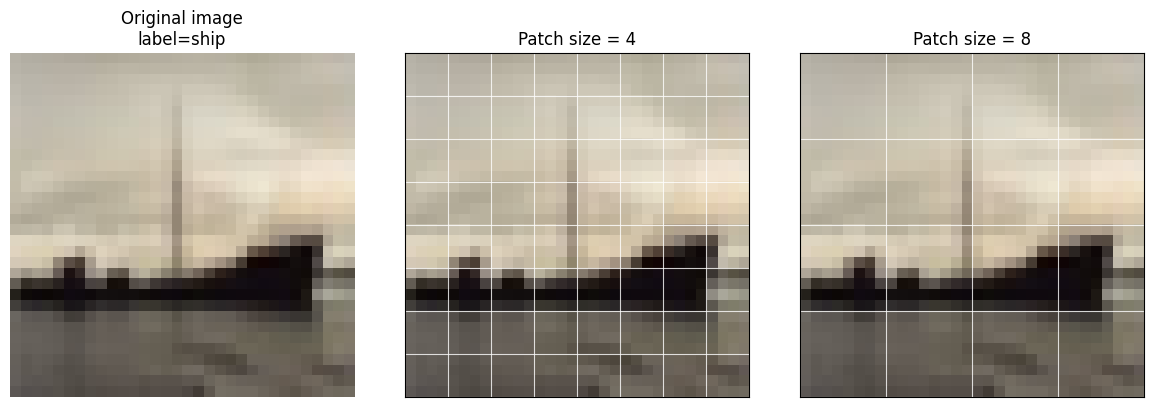

,name,patch_size,pooling,sequence_length,token_dim
0,patch4_cls,4,cls,65,128
1,patch4_mean,4,mean,64,128
2,patch8_cls,8,cls,17,128
3,patch8_mean,8,mean,16,128


In [23]:
sample_index = 7
sample_image = bundle.train_images[sample_index]
sample_label = bundle.labels[int(bundle.train_labels[sample_index])]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_image)
axes[0].set_title(f"Original image\nlabel={sample_label}")
axes[0].axis("off")
plot_patch_grid(sample_image, patch_size=4, title="Patch size = 4", ax=axes[1])
plot_patch_grid(sample_image, patch_size=8, title="Patch size = 8", ax=axes[2])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "patch_grid_preview.png", dpi=160, bbox_inches="tight")
plt.show()

token_table = pd.DataFrame([
    {"name": "patch4_cls", "patch_size": 4, "pooling": "cls", "sequence_length": sequence_length(32, 4, pooling="cls"), "token_dim": 128},
    {"name": "patch4_mean", "patch_size": 4, "pooling": "mean", "sequence_length": sequence_length(32, 4, pooling="mean"), "token_dim": 128},
    {"name": "patch8_cls", "patch_size": 8, "pooling": "cls", "sequence_length": sequence_length(32, 8, pooling="cls"), "token_dim": 128},
    {"name": "patch8_mean", "patch_size": 8, "pooling": "mean", "sequence_length": sequence_length(32, 8, pooling="mean"), "token_dim": 128},
])
token_table


In [24]:
configs = make_configs()
config_frame = pd.DataFrame([vars(config) for config in configs])
config_frame


,name,patch_size,pooling,embed_dim,depth,num_heads,mlp_ratio,dropout,batch_size,epochs,learning_rate,weight_decay
0,patch4_cls,4,cls,128,4,4,4.0,0.1,128,8,0.0003,0.0001
1,patch4_mean,4,mean,128,4,4,4.0,0.1,128,8,0.0003,0.0001
2,patch8_cls,8,cls,128,4,4,4.0,0.1,128,8,0.0003,0.0001
3,patch8_mean,8,mean,128,4,4,4.0,0.1,128,8,0.0003,0.0001


In [ ]:
experiments = []
for config in configs:
    print(f"Running experiment: {config.name}")
    experiment = run_experiment(config, bundle, device)
    experiments.append(experiment)

comparison_rows = experiment_summary_rows(experiments)
comparison_df = pd.DataFrame(comparison_rows).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
comparison_df.to_csv(OUTPUT_DIR / "comparison.csv", index=False)

comparison_df


Running experiment: patch4_cls
Running experiment: patch4_mean
Running experiment: patch8_cls
Running experiment: patch8_mean


,name,patch_size,embed_dim,depth,pooling,params,sequence_length,attn_scores_mb_per_block,attn_flops_m_per_block,forward_ms,val_accuracy,test_accuracy
0,patch4_mean,4,128,4,mean,809098,64,8.000,268.435,11.042,0.6592,0.6603
1,patch4_cls,4,128,4,cls,809354,65,8.252,276.890,10.564,0.6366,0.6411
2,patch8_mean,8,128,4,mean,821386,16,0.500,16.777,6.348,0.6158,0.6080
3,patch8_cls,8,128,4,cls,821642,17,0.564,18.940,4.581,0.5816,0.5832


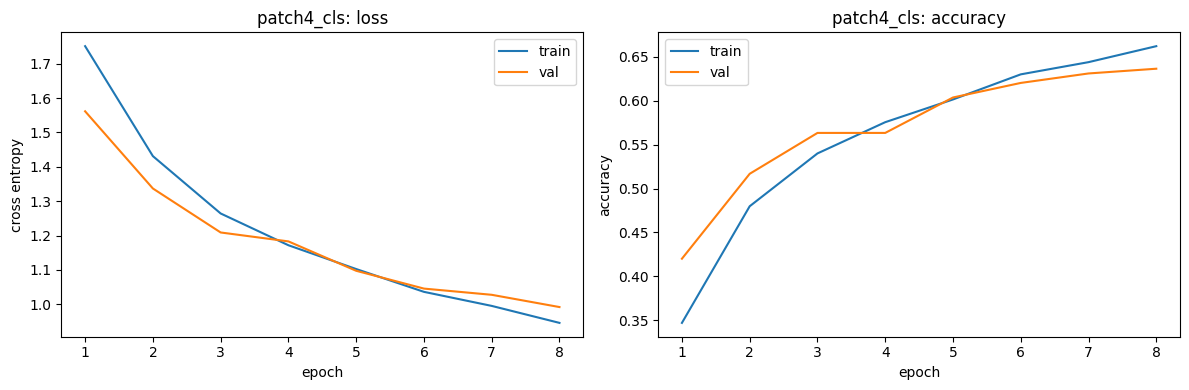

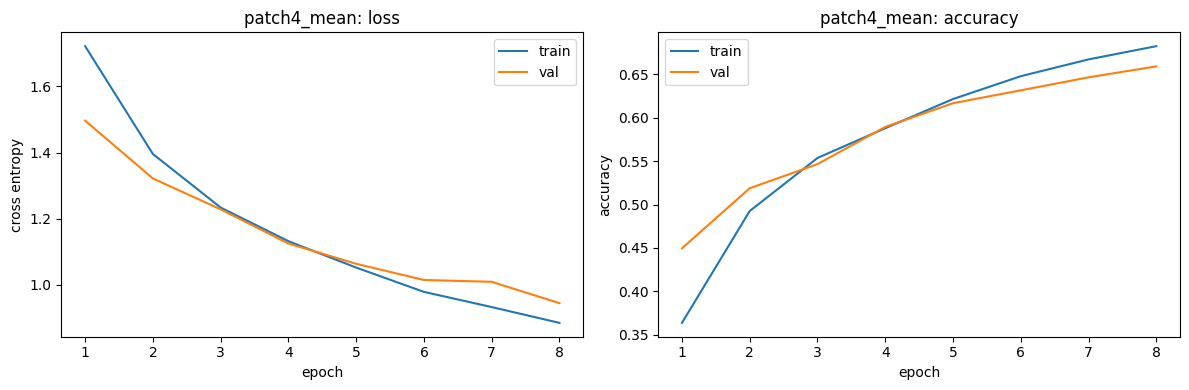

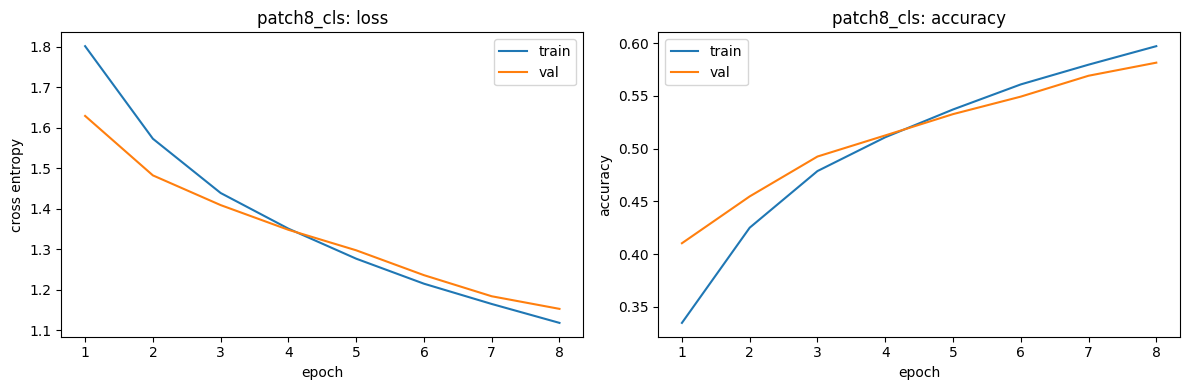

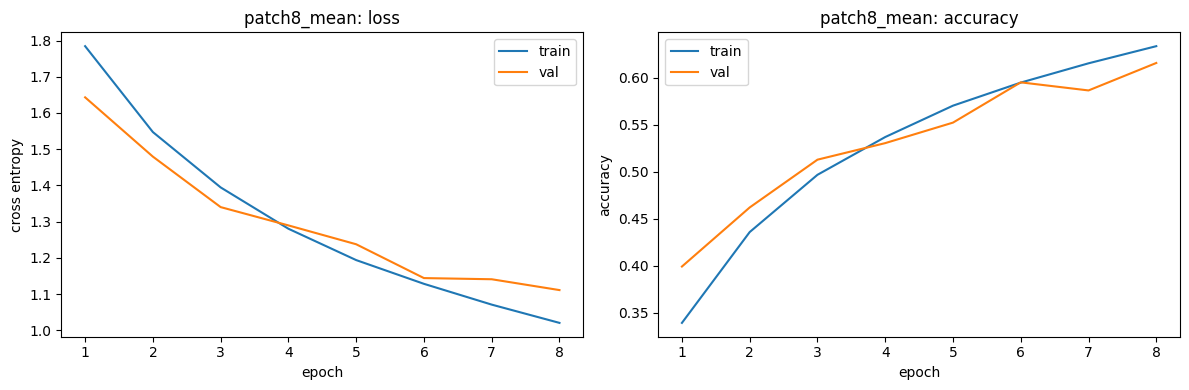

In [26]:
for experiment in experiments:
    fig = plot_training_curves(experiment["history"], experiment["config"].name)
    fig.savefig(OUTPUT_DIR / f"{experiment['config'].name}_curves.png", dpi=160, bbox_inches="tight")
    plt.show()


Best validation model: patch4_mean


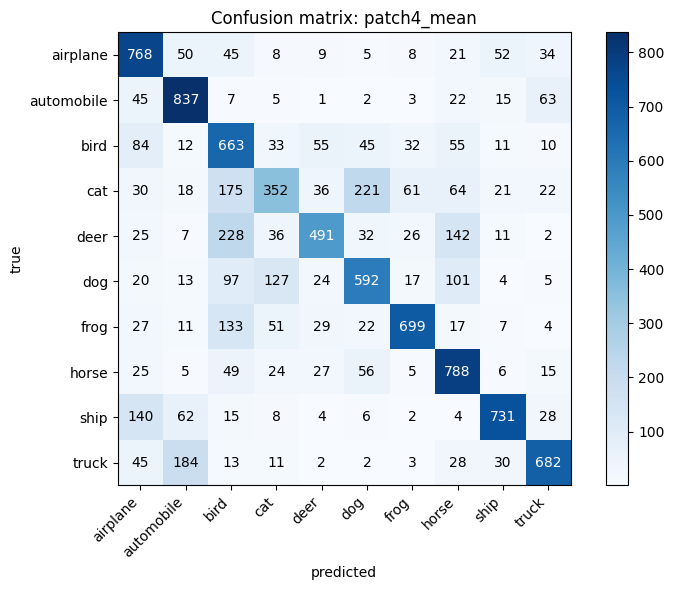

In [27]:
best_experiment = max(experiments, key=lambda exp: exp["val_metrics"]["accuracy"])
best_name = best_experiment["config"].name
print(f"Best validation model: {best_name}")
confusion_fig = plot_confusion_matrix(
    best_experiment["test_metrics"]["targets"],
    best_experiment["test_metrics"]["predictions"],
    bundle.labels,
    title=f"Confusion matrix: {best_name}",
)
confusion_fig.savefig(OUTPUT_DIR / "best_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


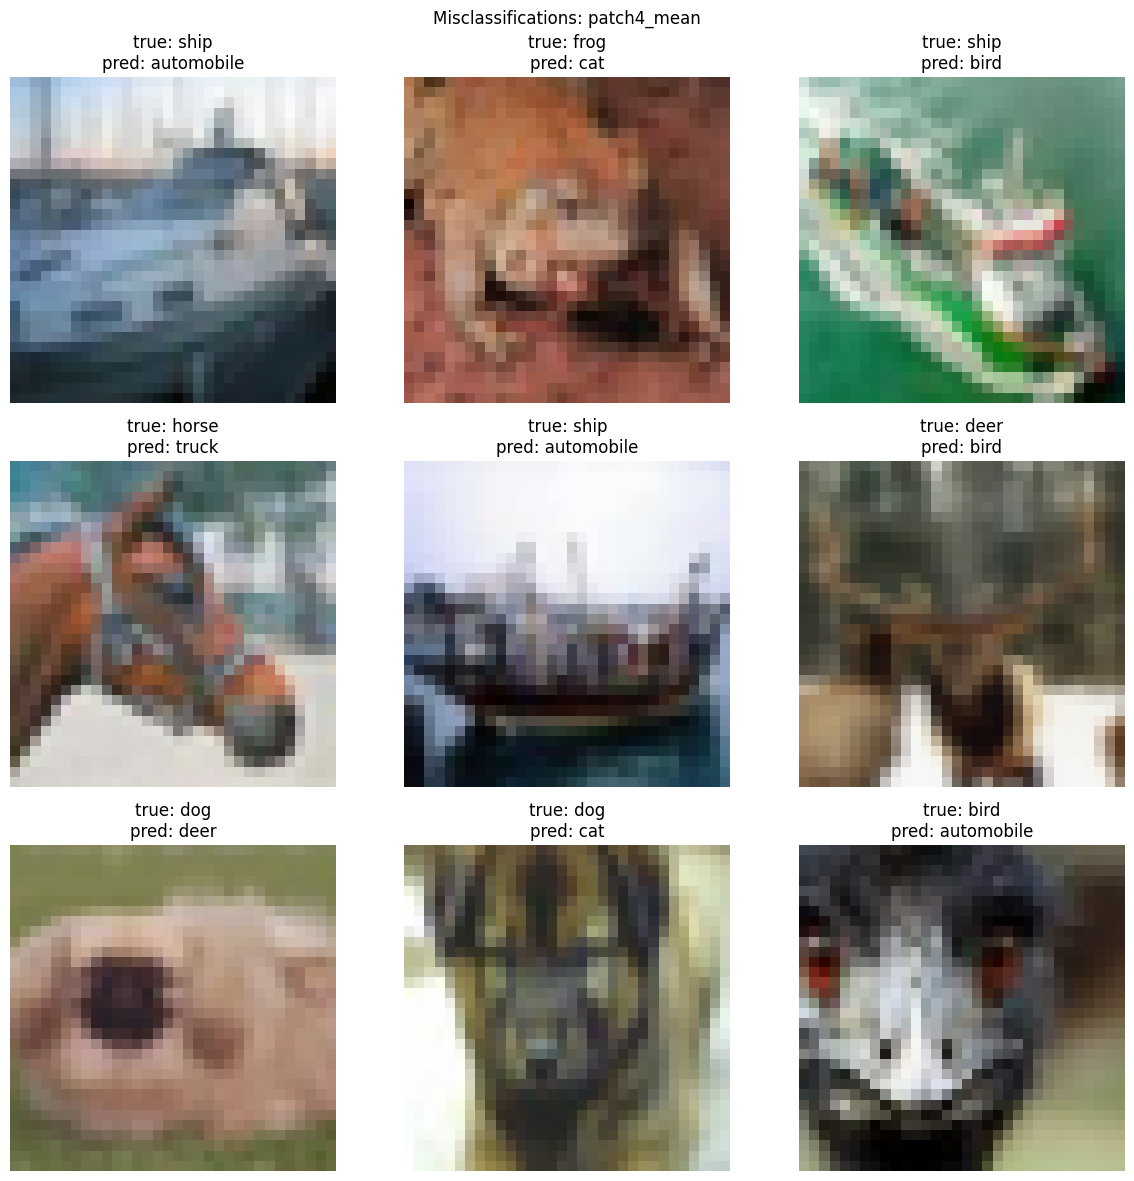

In [28]:
examples = collect_misclassified_examples(
    best_experiment["model"],
    best_experiment["loaders"]["test"],
    device,
    max_items=9,
)
fig = plot_misclassified_examples(examples, bundle.labels, title=f"Misclassifications: {best_name}")
fig.savefig(OUTPUT_DIR / "best_misclassifications.png", dpi=160, bbox_inches="tight")
plt.show()


In [29]:
cm = confusion_matrix(
    best_experiment["test_metrics"]["targets"],
    best_experiment["test_metrics"]["predictions"],
    labels=list(range(len(bundle.labels))),
)
per_class_rows = []
for idx, label in enumerate(bundle.labels):
    total = int(cm[idx].sum())
    correct = int(cm[idx, idx])
    per_class_rows.append({
        "class": label,
        "support": total,
        "correct": correct,
        "accuracy": round(correct / total, 4),
    })
per_class_df = pd.DataFrame(per_class_rows).sort_values("accuracy")
per_class_df.to_csv(OUTPUT_DIR / "per_class_accuracy.csv", index=False)

confusion_rows = []
for i, true_label in enumerate(bundle.labels):
    for j, pred_label in enumerate(bundle.labels):
        if i == j:
            continue
        count = int(cm[i, j])
        if count > 0:
            confusion_rows.append({
                "count": count,
                "true_class": true_label,
                "predicted_class": pred_label,
            })
top_confusions_df = pd.DataFrame(confusion_rows).sort_values("count", ascending=False).head(10)
top_confusions_df.to_csv(OUTPUT_DIR / "top_confusions.csv", index=False)

display(Markdown("### Lowest per-class accuracies"))
display(per_class_df.head(5).reset_index(drop=True))
display(Markdown("### Top confusion pairs"))
display(top_confusions_df.reset_index(drop=True))


### Lowest per-class accuracies

,class,support,correct,accuracy
0,cat,1000,352,0.352
1,deer,1000,491,0.491
2,dog,1000,592,0.592
3,bird,1000,663,0.663
4,truck,1000,682,0.682


### Top confusion pairs

,count,true_class,predicted_class
0,228,deer,bird
1,221,cat,dog
2,184,truck,automobile
3,175,cat,bird
4,142,deer,horse
5,140,ship,airplane
6,133,frog,bird
7,127,dog,cat
8,101,dog,horse
9,97,dog,bird


In [30]:
sample_loader = best_experiment["loaders"]["test"]
sample_batch, _ = next(iter(sample_loader))
logits, attention_maps = best_experiment["model"](sample_batch[:4].to(device), return_attention=True)
print("Number of transformer blocks:", len(attention_maps))
print("Attention map tensor shape from the final block:", attention_maps[-1].shape)
display(Markdown(
    f"**Patch size:** {best_experiment['config'].patch_size}, "
    f"**sequence length:** {int(best_experiment['attention_cost']['seq_len'])}, "
    f"**token dimension:** {best_experiment['config'].embed_dim}, "
    f"**attention memory per block:** {best_experiment['attention_cost']['attn_scores_mb_per_block']:.3f} MB."
))


Number of transformer blocks: 4
Attention map tensor shape from the final block: torch.Size([4, 4, 64, 64])


**Patch size:** 4, **sequence length:** 64, **token dimension:** 128, **attention memory per block:** 8.000 MB.